Step 1 — Import Libraries
We need pandas (data), numpy (numbers), matplotlib/seaborn (charts), and scikit-learn (ML).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
print("Libraries loaded ")

Libraries loaded ✅


Step 2 — Load the Dataset

In [ ]:
import pandas as pd
df = pd.read_csv(r"D:\Ai research analyst\day8\Housing.csv")

## Step 3 — Look at the Data

In [5]:
# See column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
# Basic statistics of numeric columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# Check for missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Step 4 — Clean the Data
The dataset has columns like mainroad, guestroom with values *yes/no*.  
Computers don't understand words, so we convert them into **0 and 1**.

In [ ]:
# Convert yes/no columns to 1/0
yes_no_cols = ['mainroad','guestroom','basement','hotwaterheating',
               'airconditioning','prefarea']
for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Convert True/False dummy cols to 1/0
for c in df.select_dtypes(include=['bool']).columns:
    df[c] = df[c].astype(int)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


Step 5 — Visualization

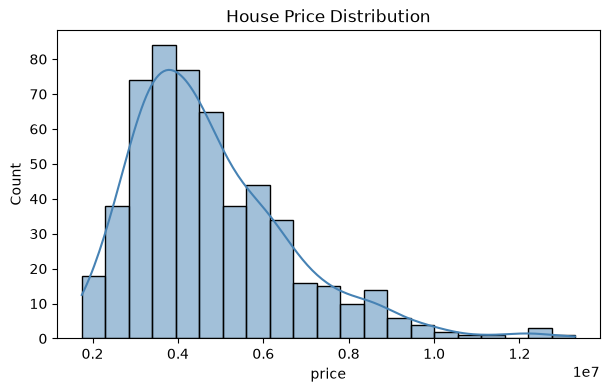

In [ ]:
# Distribution of house prices
plt.figure(figsize=(5,4))
sns.histplot(df['price'],  color='steelblue')
plt.title("House Price Distribution")
plt.show()

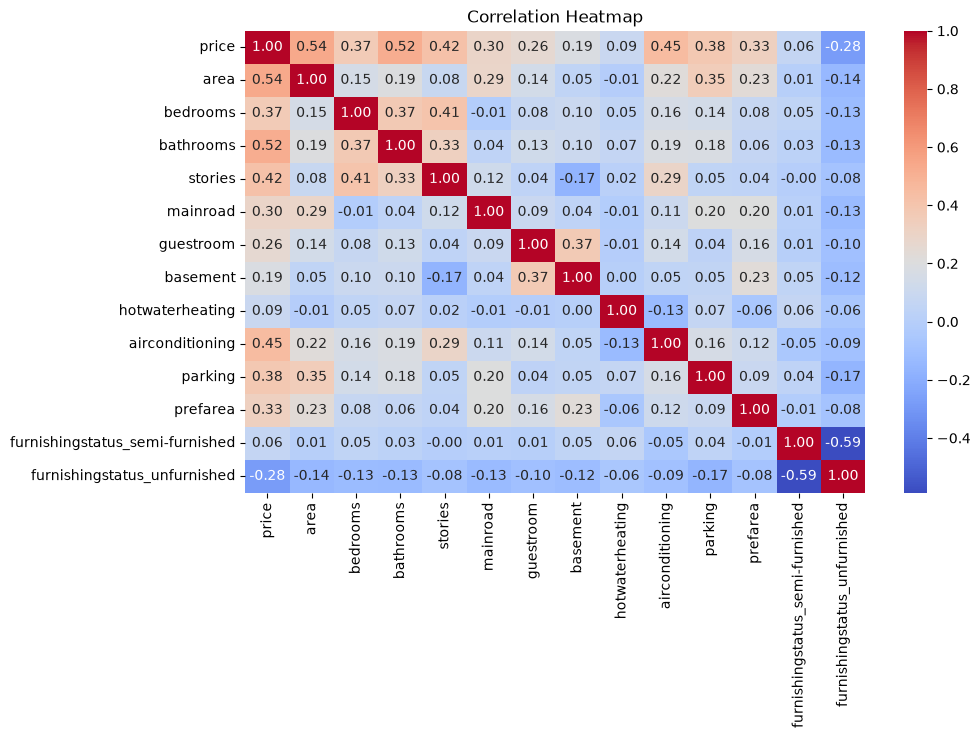

In [10]:
# Correlation heatmap — shows which features affect price most
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Step 6 — Split Data
X = input features (all columns except price)  
y = target   
We split 80% for training and 20% for testing.

In [11]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 436
Testing rows : 109


Step 7 — Train the Model
We use Linear Regression — the simplest ML model.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained ")

Model trained ✅


## Step 8 — Check How Good the Model Is

In [13]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}   (closer to 1 = better)")

MAE  : 970,043.40
MSE  : 1,754,318,687,330.66
RMSE : 1,324,506.96
R²   : 0.653   (closer to 1 = better)


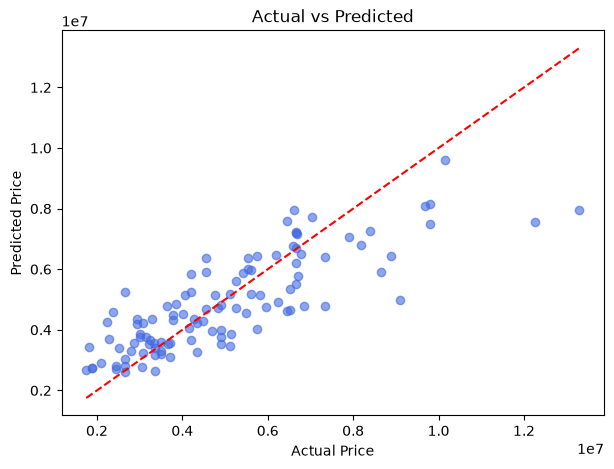

In [14]:
# Compare actual vs predicted visually
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Step 9 — Predict a New House 

In [20]:
new_house = {
    'area': 600,
    'bedrooms': 2,
    'bathrooms': 1,
    'stories': 0,
    'mainroad': 0,
    'guestroom': 0,
    'basement': 1,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 1,
    'prefarea': 1,
    'furnishingstatus_semi-furnished': 1,
    'furnishingstatus_unfurnished': 0,
}

# Make sure the order of columns matches the training data
new_df = pd.DataFrame([new_house])[X.columns]

predicted_price = model.predict(new_df)[0]
print(f" Predicted House Price: {predicted_price:,.2f}")

 Predicted House Price: 3,559,144.40


Step 10 — Save the Model
So we can reuse it later without training again.

In [16]:
joblib.dump(model, "house_price_model.pkl")
print("Model saved as house_price_model.pkl ✅")

# Load it back to verify
loaded_model = joblib.load("house_price_model.pkl")
print("Loaded model works:", loaded_model.predict(new_df)[0])

Model saved as house_price_model.pkl ✅
Loaded model works: 7187472.572638668
